# HNSW 在 NetVLAD 特征上的性能分析（余弦相似度）

思路：先对 NetVLAD 特征做 L2 归一化，然后在单位球面上用 L2 距离/内积近似 **余弦相似度**，
比较 HNSW 与暴力检索（FAISS Flat-IP）的 Recall 与检索时间。

In [2]:
import sys
from pathlib import Path

# 确保能导入 ch3 下的 demo_readH5（若 kernel 的 cwd 是 hnsw_performance_analysis）
_nb_dir = Path().resolve()
if _nb_dir.name == "hnsw_performance_analysis":
    sys.path.insert(0, str(_nb_dir.parent))

import numpy as np
import faiss
import matplotlib.pyplot as plt
import time

from demo_readH5 import load_netvlad_descriptors, load_multi_netvlad_descriptors, DB_H5_PATHS, QUERY_H5_PATHS

## 1. 读取 NetVLAD H5（合并多个 DB 文件）

In [3]:
# 将多个 DB H5 合并为一个大数据库
print("从多个 DB H5 读取并合并 NetVLAD 描述子...")
db_names, db_descs = load_multi_netvlad_descriptors(DB_H5_PATHS)

print("从多个 Query H5 读取并合并 NetVLAD 描述子...")
query_names, query_descs = load_multi_netvlad_descriptors(QUERY_H5_PATHS)

db_descs = db_descs.astype(np.float32)
query_descs = query_descs.astype(np.float32)

print(f"DB (multi):    {len(db_names)} 条, shape {db_descs.shape}")
print(f"Query (multi): {len(query_names)} 条, shape {query_descs.shape}")

从多个 DB H5 读取并合并 NetVLAD 描述子...
从多个 Query H5 读取并合并 NetVLAD 描述子...
DB (multi):    11009 条, shape (11009, 4096)
Query (multi): 1235 条, shape (1235, 4096)


## 2. L2 归一化 & 用 FAISS Flat-IP 生成 Ground Truth（余弦相似度）

对向量做 L2 归一化后：
- 余弦相似度 cos = 内积(IP)
- L2 距离 与 IP 单调等价，可互换用于最近邻排序。

In [5]:
def l2_normalize(x: np.ndarray, axis: int = 1, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(x, axis=axis, keepdims=True)
    return x / np.maximum(norms, eps)


db_norm = l2_normalize(db_descs)
query_norm = l2_normalize(query_descs)

# Ground truth: 使用内积（等价于余弦）做暴力检索，支持缓存到本地，并统计暴力检索时间
K_GT = min(10, len(db_norm))

gt_path = Path("/home/lty/code_my/ch3/gt_netvlad_cosine_multi.npz")
if gt_path.exists():
    data = np.load(gt_path)
    I_gt = data["I_gt"]
    D_gt = data["D_gt"]
    # 若缓存的 K_GT 与当前不一致，则重新生成
    K_from_file = int(data.get("K_GT", I_gt.shape[1]))
    if K_from_file != K_GT:
        print(f"检测到缓存 K_GT={K_from_file} 与当前 K_GT={K_GT} 不一致，重新生成真值...")
        gt_path.unlink(missing_ok=True)
        # 重新生成
        d = db_norm.shape[1]
        index_gt = faiss.IndexFlatIP(d)
        index_gt.add(db_norm)
        t0 = time.perf_counter()
        D_gt, I_gt = index_gt.search(query_norm, K_GT)
        t_bf = time.perf_counter() - t0
        t_bf_per_query_ms = (t_bf / len(query_norm)) * 1000
        gt_path.parent.mkdir(parents=True, exist_ok=True)
        np.savez(gt_path, I_gt=I_gt, D_gt=D_gt, K_GT=K_GT, t_bf=t_bf, t_bf_per_query_ms=t_bf_per_query_ms)
        print(f"Ground truth (cosine/IP) 已重新生成并缓存到: {gt_path}, I_gt {I_gt.shape}, D_gt {D_gt.shape}")
        print(f"暴力检索总耗时: {t_bf:.3f} s, 平均每 query: {t_bf_per_query_ms:.4f} ms")
    else:
        t_bf = float(data.get("t_bf", -1.0))
        t_bf_per_query_ms = float(data.get("t_bf_per_query_ms", -1.0))
        print(f"从缓存加载 Ground truth: {gt_path}, I_gt {I_gt.shape}, D_gt {D_gt.shape}")
        if t_bf > 0:
            print(f"缓存中的暴力检索总耗时: {t_bf:.3f} s, 平均每 query: {t_bf_per_query_ms:.4f} ms")
else:
    d = db_norm.shape[1]
    index_gt = faiss.IndexFlatIP(d)
    index_gt.add(db_norm)
    t0 = time.perf_counter()
    D_gt, I_gt = index_gt.search(query_norm, K_GT)
    t_bf = time.perf_counter() - t0
    t_bf_per_query_ms = (t_bf / len(query_norm)) * 1000
    gt_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(gt_path, I_gt=I_gt, D_gt=D_gt, K_GT=K_GT, t_bf=t_bf, t_bf_per_query_ms=t_bf_per_query_ms)
    print(f"Ground truth (cosine/IP) 已生成并缓存到: {gt_path}, I_gt {I_gt.shape}, D_gt {D_gt.shape}")
    print(f"暴力检索总耗时: {t_bf:.3f} s, 平均每 query: {t_bf_per_query_ms:.4f} ms")

从缓存加载 Ground truth: /home/lty/code_my/ch3/gt_netvlad_cosine_multi.npz, I_gt (1235, 10), D_gt (1235, 10)


## 3. Recall@k 与 HNSW 构建/检索辅助函数（在单位球面上用 L2）

In [6]:
def recall_at_k(pred_I: np.ndarray, gt_I: np.ndarray, k: int) -> float:
    """pred_I: (N_q, topk), gt_I: (N_q, K_GT)。计算 Recall@k。"""
    nq = pred_I.shape[0]
    recalls = []
    for i in range(nq):
        pred_set = set(pred_I[i, :k])
        gt_set = set(gt_I[i, :k])
        if not gt_set:
            recalls.append(1.0)
        else:
            recalls.append(len(pred_set & gt_set) / len(gt_set))
    return float(np.mean(recalls))


def build_hnsw_and_search_cosine(db: np.ndarray, q: np.ndarray, k: int, M: int, ef_c: int, ef_s: int):
    """在已 L2 归一化的向量上构建 HNSW（L2），等价于余弦空间上的最近邻。"""
    d = db.shape[1]
    index = faiss.IndexHNSWFlat(d, M)  # L2 on unit vectors ~ cosine
    index.hnsw.efConstruction = ef_c
    index.hnsw.efSearch = ef_s
    t0 = time.perf_counter()
    index.add(db)
    t_build = time.perf_counter() - t0
    t1 = time.perf_counter()
    D, I = index.search(q, k)
    t_search = time.perf_counter() - t1
    return index, I, D, t_build, t_search

In [7]:
# 统一结果输出目录（相对当前 notebook 路径）
results_root = Path("results")
results_root.mkdir(exist_ok=True)


def save_hnsw_results(index, I, D, db_names, query_names, tag: str):
    """保存 HNSW 索引和检索结果到 results_cosine 目录。"""
    # 保存索引
    index_path = results_root / f"hnsw_cosine_{tag}.index"
    faiss.write_index(index, str(index_path))

    # 保存检索结果 txt：每行 query_name db_name distance
    txt_path = results_root / f"hnsw_cosine_{tag}.txt"
    with txt_path.open("w", encoding="utf-8") as f:
        num_queries, topk = I.shape
        for qi in range(num_queries):
            q_name = query_names[qi]
            for rank in range(topk):
                db_idx = I[qi, rank]
                dist = D[qi, rank]
                db_name = db_names[db_idx]
                f.write(f"{q_name} {db_name} {float(dist):.6f}\n")

## 4. efSearch 网格搜索：Recall（相对余弦真值）与查询时间

In [8]:
# 小规模数据：M 和 efSearch 用相对较小的值即可
M_fixed = 24
ef_construction_fixed = 200
ef_search_values = [1, 5, 10, 20, 35, 50, 75, 100, 125, 150, 175, 200]
k_eval = min(10, K_GT)

recalls_ef = []
times_per_query_ms = []

for ef_s in ef_search_values:
    index, I, D, t_build, t_search = build_hnsw_and_search_cosine(
        db_norm, query_norm, k_eval,
        M=M_fixed, ef_c=ef_construction_fixed, ef_s=ef_s
    )
    r = recall_at_k(I, I_gt, k_eval)
    recalls_ef.append(r)
    t_pq = (t_search / len(query_norm)) * 1000
    times_per_query_ms.append(t_pq)
    print(f"efSearch={ef_s:4d}  Recall@{k_eval}={r:.4f}  time/query={t_pq:.4f} ms")

    # 保存索引和检索结果
    tag = f"M{M_fixed}_efc{ef_construction_fixed}_efs{ef_s}"
    save_hnsw_results(index, I, D, db_names, query_names, tag)

recalls_ef = np.array(recalls_ef)
times_per_query_ms = np.array(times_per_query_ms)

efSearch=   1  Recall@10=0.2648  time/query=0.0068 ms
efSearch=   5  Recall@10=0.5422  time/query=0.0150 ms
efSearch=  10  Recall@10=0.6832  time/query=0.0196 ms
efSearch=  20  Recall@10=0.8040  time/query=0.0294 ms
efSearch=  35  Recall@10=0.8768  time/query=0.0525 ms
efSearch=  50  Recall@10=0.9397  time/query=0.0603 ms
efSearch=  75  Recall@10=0.9688  time/query=0.0846 ms
efSearch= 100  Recall@10=0.9862  time/query=0.1094 ms
efSearch= 125  Recall@10=0.9900  time/query=0.1409 ms
efSearch= 150  Recall@10=0.9942  time/query=0.1714 ms
efSearch= 175  Recall@10=0.9958  time/query=0.1967 ms
efSearch= 200  Recall@10=0.9977  time/query=0.2104 ms


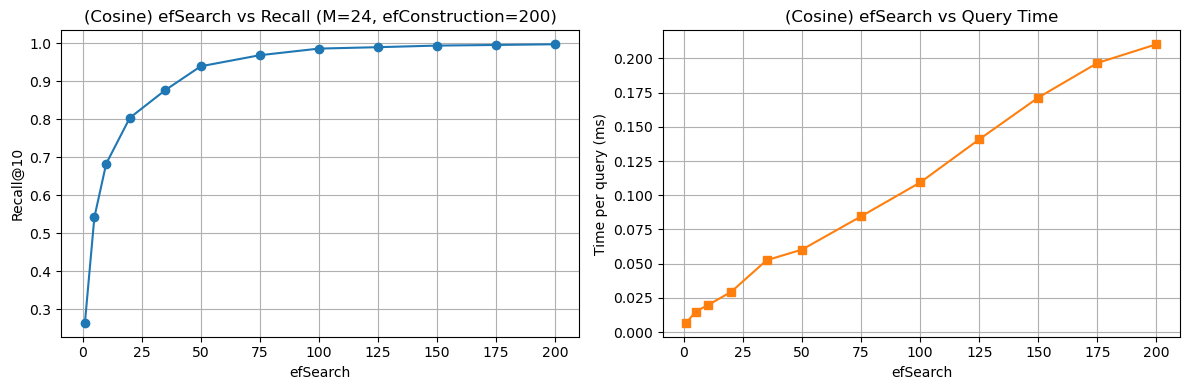

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ef_search_values, recalls_ef, marker="o")
ax1.set_xlabel("efSearch")
ax1.set_ylabel(f"Recall@{k_eval}")
ax1.set_title(f"(Cosine) efSearch vs Recall (M={M_fixed}, efConstruction={ef_construction_fixed})")
ax1.grid(True)

ax2.plot(ef_search_values, times_per_query_ms, marker="s", color="C1")
ax2.set_xlabel("efSearch")
ax2.set_ylabel("Time per query (ms)")
ax2.set_title("(Cosine) efSearch vs Query Time")
ax2.grid(True)

plt.tight_layout()
plt.show()

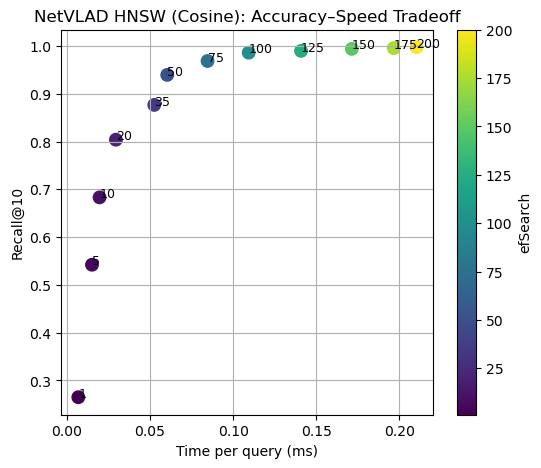

In [10]:
# 精度-速度权衡：Recall vs Time per query（余弦）
plt.figure(figsize=(6, 5))
plt.scatter(times_per_query_ms, recalls_ef, s=80, c=ef_search_values, cmap="viridis")
for i, ef in enumerate(ef_search_values):
    plt.annotate(str(ef), (times_per_query_ms[i], recalls_ef[i]), fontsize=9)
plt.xlabel("Time per query (ms)")
plt.ylabel(f"Recall@{k_eval}")
plt.title("NetVLAD HNSW (Cosine): Accuracy–Speed Tradeoff")
plt.colorbar(label="efSearch")
plt.grid(True)
plt.show()

## 5. M 与 efConstruction 对（余弦）Recall 的影响

In [11]:
ef_search_fixed = 50
M_values = [8, 16, 24, 32]
ef_construction_values = [20, 50, 100, 200]

results_M_efC = []  # list of (M, ef_c, recall, time_per_query_ms)

for M in M_values:
    for ef_c in ef_construction_values:
        index, I, D, t_build, t_search = build_hnsw_and_search_cosine(
            db_norm, query_norm, k_eval,
            M=M, ef_c=ef_c, ef_s=ef_search_fixed
        )
        r = recall_at_k(I, I_gt, k_eval)
        t_pq = (t_search / len(query_norm)) * 1000
        results_M_efC.append((M, ef_c, r, t_pq))
        print(f"M={M}, efConstruction={ef_c}  Recall@{k_eval}={r:.4f}  time/query={t_pq:.4f} ms")

        # 保存当前参数组合的索引和检索结果
        tag = f"M{M}_efc{ef_c}_efs{ef_search_fixed}"
        save_hnsw_results(index, I, D, db_names, query_names, tag)

results_M_efC = np.array(results_M_efC)

M=8, efConstruction=20  Recall@10=0.5517  time/query=0.0234 ms
M=8, efConstruction=50  Recall@10=0.6725  time/query=0.0285 ms
M=8, efConstruction=100  Recall@10=0.8021  time/query=0.0332 ms
M=8, efConstruction=200  Recall@10=0.8849  time/query=0.0432 ms
M=16, efConstruction=20  Recall@10=0.5876  time/query=0.0292 ms
M=16, efConstruction=50  Recall@10=0.7633  time/query=0.0306 ms
M=16, efConstruction=100  Recall@10=0.8649  time/query=0.0412 ms
M=16, efConstruction=200  Recall@10=0.9260  time/query=0.0511 ms
M=24, efConstruction=20  Recall@10=0.6401  time/query=0.0315 ms
M=24, efConstruction=50  Recall@10=0.7812  time/query=0.0301 ms
M=24, efConstruction=100  Recall@10=0.8807  time/query=0.0409 ms
M=24, efConstruction=200  Recall@10=0.9338  time/query=0.0560 ms
M=32, efConstruction=20  Recall@10=0.6609  time/query=0.0380 ms
M=32, efConstruction=50  Recall@10=0.7691  time/query=0.0696 ms
M=32, efConstruction=100  Recall@10=0.8869  time/query=0.0476 ms
M=32, efConstruction=200  Recall@10=0

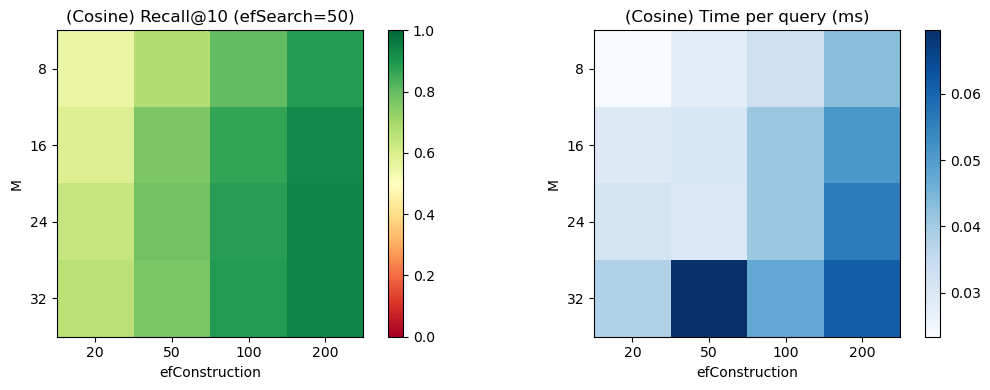

In [12]:
# Recall / 时间 热力图：M x efConstruction（余弦）
recall_grid = np.zeros((len(M_values), len(ef_construction_values)))
time_grid = np.zeros((len(M_values), len(ef_construction_values)))
idx = 0
for i, M in enumerate(M_values):
    for j, ef_c in enumerate(ef_construction_values):
        recall_grid[i, j] = results_M_efC[idx, 2]
        time_grid[i, j] = results_M_efC[idx, 3]
        idx += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

im1 = ax1.imshow(recall_grid, cmap="RdYlGn", vmin=0, vmax=1)
ax1.set_xticks(range(len(ef_construction_values)))
ax1.set_xticklabels(ef_construction_values)
ax1.set_yticks(range(len(M_values)))
ax1.set_yticklabels(M_values)
ax1.set_xlabel("efConstruction")
ax1.set_ylabel("M")
ax1.set_title(f"(Cosine) Recall@{k_eval} (efSearch={ef_search_fixed})")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(time_grid, cmap="Blues")
ax2.set_xticks(range(len(ef_construction_values)))
ax2.set_xticklabels(ef_construction_values)
ax2.set_yticks(range(len(M_values)))
ax2.set_yticklabels(M_values)
ax2.set_xlabel("efConstruction")
ax2.set_ylabel("M")
ax2.set_title("(Cosine) Time per query (ms)")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

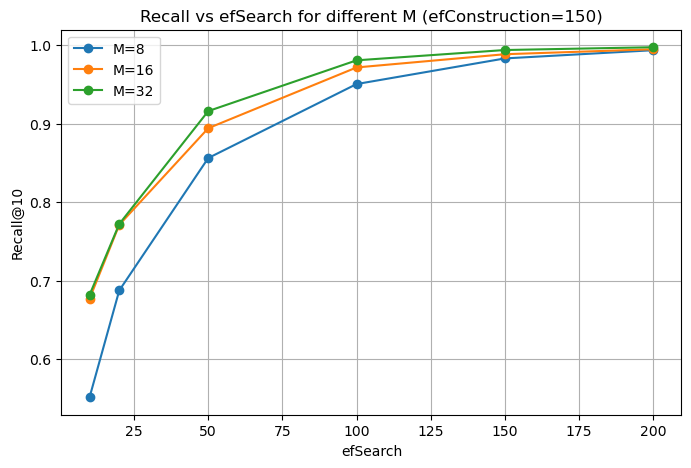

In [14]:
ef_search_list = [10, 20, 50, 100, 150, 200]
M_list_for_curves = [8, 16, 32]
ef_c_fixed = 150

plt.figure(figsize=(8, 5))
for M in M_list_for_curves:
    recs = []
    for ef_s in ef_search_list:
        index, I, D, t_build, t_search = build_hnsw_and_search_cosine(
            db_descs, query_descs, k_eval,
            M=M, ef_c=ef_c_fixed, ef_s=ef_s
        )
        recs.append(recall_at_k(I, I_gt, k_eval))
    plt.plot(ef_search_list, recs, marker="o", label=f"M={M}")

plt.xlabel("efSearch")
plt.ylabel(f"Recall@{k_eval}")
plt.title(f"Recall vs efSearch for different M (efConstruction={ef_c_fixed})")
plt.legend()
plt.grid(True)
plt.show()

## 6. 小结（余弦相似度）

- 通过对 NetVLAD 向量做 L2 归一化，我们在单位球面上用 L2/HNSW 近似余弦最近邻；
- Ground truth 用 FAISS Flat-IP 暴力检索，直接等价于余弦相似度；
- efSearch、M、efConstruction 对 Recall 与时间的影响，与 L2 情况类似，但数值上略有差异。
